First 5 rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   69    1   0       160   234    1        2      131      0      0.1      1   
1   69    0   0       140   239    0        0      151      0      1.8      0   
2   66    0   0       150   226    0        0      114      0      2.6      2   
3   65    1   0       138   282    1        2      174      0      1.4      1   
4   64    1   0       110   211    0        2      144      1      1.8      1   

   ca  thal  condition  
0   1     0          0  
1   2     0          0  
2   0     0          0  
3   1     0          1  
4   0     0          0  

Columns in dataset:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'condition'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  -

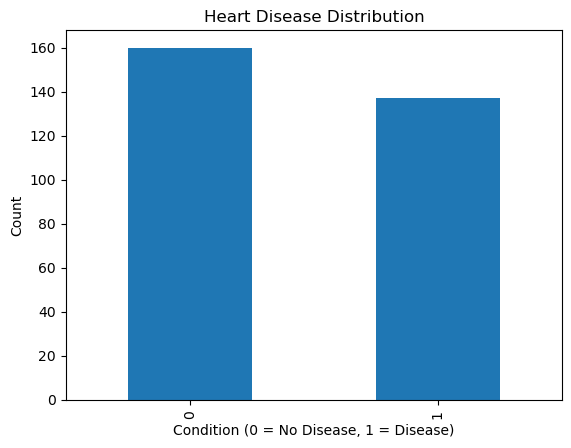


Feature shape: (297, 13)
Target shape: (297,)

Training Data Size: (237, 13)
Testing Data Size: (60, 13)

===== Logistic Regression Model =====
Logistic Regression Accuracy: 0.7333333333333333

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.72      0.74        32
           1       0.70      0.75      0.72        28

    accuracy                           0.73        60
   macro avg       0.73      0.73      0.73        60
weighted avg       0.74      0.73      0.73        60


Confusion Matrix:
[[23  9]
 [ 7 21]]

===== Decision Tree Model =====
Decision Tree Accuracy: 0.7666666666666667

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.75      0.77        32
           1       0.73      0.79      0.76        28

    accuracy                           0.77        60
   macro avg       0.77      0.77      0.77        60
weighted avg       0.77      0.77      0.77  

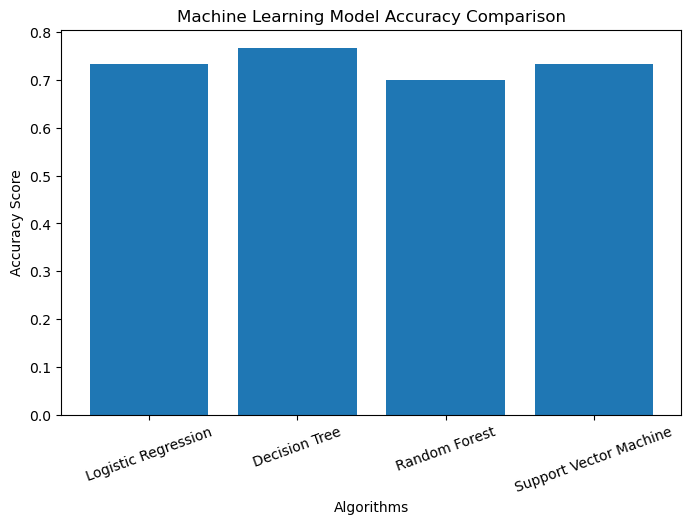

In [2]:
# ===========================
# MEMBER 1 – DATA PREPARATION
# ===========================

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#loading dataset
data = pd.read_csv("heart_cleveland_upload.csv")

print("First 5 rows:")
print(data.head())

print("\nColumns in dataset:")
print(data.columns)

#basic information

print("\nDataset Info:")
print(data.info())

print("\nStatistical Summary:")
print(data.describe())

# HANDLE MISSING VALUES

# Replace '?' with NaN
data = data.replace("?", np.nan)

# Convert all columns to numeric
data = data.apply(pd.to_numeric)

# Drop missing values
data = data.dropna()

print("\nMissing values after cleaning:")
print(data.isnull().sum())

# DATA VISUALIZATION

# Check target column name first
print("\nChecking target column name...")
print(data.columns)

# Usually it's 'condition' in this dataset
target_column = "condition"

# Plot class distribution
data[target_column].value_counts().plot(kind='bar')
plt.title("Heart Disease Distribution")
plt.xlabel("Condition (0 = No Disease, 1 = Disease)")
plt.ylabel("Count")
plt.show()

# FEATURE & TARGET SPLIT

X = data.drop(target_column, axis=1)
y = data[target_column]

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)


# TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTraining Data Size:", X_train.shape)
print("Testing Data Size:", X_test.shape)

#Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ===========================
# MEMBER 2 –ALGORITHMS 1 & 2
# ===========================


# MACHINE LEARNING MODELS
# Logistic Regression + Decision Tree

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ALGORITHM 1 – LOGISTIC REGRESSION
print("\n===== Logistic Regression Model =====")

# Create model
log_model = LogisticRegression(max_iter=1000, solver='liblinear')

# Train model
log_model.fit(X_train, y_train)

# Make predictions
log_predictions = log_model.predict(X_test)

# Evaluate model
log_accuracy = accuracy_score(y_test, log_predictions)

print("Logistic Regression Accuracy:", log_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, log_predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, log_predictions))

# ALGORITHM 2 – DECISION TREE
print("\n===== Decision Tree Model =====")

# Create model
tree_model = DecisionTreeClassifier(random_state=42)

# Train model
tree_model.fit(X_train, y_train)

# Make predictions
tree_predictions = tree_model.predict(X_test)

# Evaluate model
tree_accuracy = accuracy_score(y_test, tree_predictions)

print("Decision Tree Accuracy:", tree_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, tree_predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, tree_predictions))


# ============================
# MEMBER 3 – ALGORITHMS 3 & 4
# ============================
 
# MACHINE LEARNING MODELS
# Random Forest + Support Vector Machine
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ALGORITHM 3 – RANDOM FOREST

print("\n===== Random Forest Model =====")
# Create model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train model
rf_model.fit(X_train, y_train)

# Make predictions
rf_predictions = rf_model.predict(X_test)

# Evaluate model
rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy:", rf_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, rf_predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_predictions))


# ALGORITHM 4 – SUPPORT VECTOR MACHINE
print("\n===== Support Vector Machine Model =====")

# Create model
svm_model = SVC()

# Train model
svm_model.fit(X_train, y_train)

# Make predictions
svm_predictions = svm_model.predict(X_test)

# Evaluate model
svm_accuracy = accuracy_score(y_test, svm_predictions)

print("SVM Accuracy:", svm_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, svm_predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, svm_predictions))


# =====================================
# MEMBER 4 – RESULT ANALYSIS COMPARISON
# =====================================

import matplotlib.pyplot as plt
import pandas as pd


# STORE RESULTS
results = {
    "Logistic Regression": log_accuracy,
    "Decision Tree": tree_accuracy,
    "Random Forest": rf_accuracy,
    "Support Vector Machine": svm_accuracy
}

# PRINT RESULTS
print("\n===== MODEL ACCURACY RESULTS =====")

for model, accuracy in results.items():
    print(model, ":", round(accuracy * 100, 2), "%")


# CREATE RESULTS TABLE
results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])

print("\nResults Table:")
print(results_df)


# FIND BEST MODEL
best_model = max(results, key=results.get)

print("\nBest Performing Model:", best_model)


# VISUALIZATION
models = list(results.keys())
accuracies = list(results.values())

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)

plt.title("Machine Learning Model Accuracy Comparison")
plt.xlabel("Algorithms")
plt.ylabel("Accuracy Score")

plt.xticks(rotation=20)

plt.show()


